Delegate: Tan De Jiun  
Date: 25 May 2026

## A — Explanation of entropy in classification
$$H(X) = -\sum_{i=1}^{n} P(x_i) \log P(x_i)$$

where 
-$H(X)$ is the entropy of random variable $X$
-$P(x_i)$ denotes the probability of each possible outcome $x_i$
-$n$ is the total number of possible outcomes.

Entropy measures the uncertainty of a random variable. Low entropy means low uncertainty, the partition effectively separates classes and the model can assign class labels. High entropy means high uncertainty, and the partition is less effective at separating classes.

**(a) Statement: High entropy means the partitions are pure. — False.**  
High entropy reflects high uncertainty in assigning a class label to samples within a partition. When entropy is high, multiple classes coexist in similar proportions within the node, the partition has failed to isolate one class. Hence, it is impure.

**(b) Statement: High entropy means the partitions are impure. — True.**  
A partition is pure when it contains predominantly one class, which corresponds to low entropy. High entropy arises when the class distribution within a node is mixed, the model is equally uncertain about which class a sample belongs to. Such a node is by definition impure, confirming the statement.

In [3]:
# Import libraries for B1 and B2 works
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import warnings
import seaborn as sns
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

## B — Feature selection using the funnelling approach
### B1. Data & raw features
In this project, we use iShares Silver Trust ETF (YahooFinance ticker: SLV), a commodity ETF tracking the silver spot price listed on NYSE Arca. Daily OHLCV (Open, High, Low, Close, Volume) data spanning 28 Apr 2006 to 20 May 2026 was sourced via YahooFinance, yielding 5,047 observations across 5 fields with no missing values.

In [4]:
# Download data
# df = yf.download('SLV', start='2006-04-28', auto_adjust=True)
# df.columns = df.columns.droplevel(1)
# df.to_csv('slv.csv')

# Read data
df = pd.read_csv('slv_2006_2026.csv', index_col=0, parse_dates=True)
print(df)

                Close       High        Low       Open    Volume
Date                                                            
2006-04-28  13.812000  13.980000  12.870000  12.900000  23432000
2006-05-01  13.870000  14.179000  13.750000  13.920000  14835000
2006-05-02  14.365000  14.400000  14.100000  14.245000  12511000
2006-05-03  13.925000  14.464000  13.413000  14.450000  15141000
2006-05-04  14.000000  14.287000  13.680000  13.950000  11075000
...               ...        ...        ...        ...       ...
2026-05-14  75.510002  77.290001  75.389999  77.290001  27151500
2026-05-15  69.040001  70.059998  68.550003  69.739998  45770100
2026-05-18  69.940002  70.769997  68.879997  70.230003  22926600
2026-05-19  66.900002  67.800003  66.110001  66.680000  23057300
2026-05-20  68.730003  69.330002  67.330002  67.820000  22298100

[5047 rows x 5 columns]


The daily log return is computed as the first difference of the log closing price:

$$r_t = \ln(Close_t) - \ln(Close_{t-1}) = \ln\left(\frac{Close_t}{Close_{t-1}}\right)$$

The first observation yields a `NaN` return and is dropped via `dropna`, leaving 5,046 usable observations. Descriptive statistics across all fields are shown below.

In [5]:
df['Return'] = np.log(df['Close']).diff()
df.dropna(inplace=True)
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Close,5046.0,2.135172e+01,1.044615e+01,8.850000e+00,1.524000e+01,1.815000e+01,2.421750e+01,1.056000e+02
High,5046.0,2.156087e+01,1.062892e+01,9.050000e+00,1.536000e+01,1.829500e+01,2.437750e+01,1.098300e+02
Low,5046.0,2.112166e+01,1.020208e+01,8.450000e+00,1.512000e+01,1.799000e+01,2.398750e+01,1.000000e+02
Open,5046.0,2.135626e+01,1.044671e+01,8.710000e+00,1.525025e+01,1.815600e+01,2.421000e+01,1.095300e+02
Volume,5046.0,1.700770e+07,2.156629e+07,1.039000e+06,6.503775e+06,1.120625e+07,2.022510e+07,5.106877e+08
Return,5046.0,3.180040e-04,2.119011e-02,-3.360366e-01,-8.729692e-03,9.435192e-04,1.041456e-02,1.347326e-01


In [6]:
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
Return    0
dtype: int64

A total of 23 technical indicators were constructed as candidate features across six categories. All features are derived solely from past price and volume data to prevent look-ahead bias.

**Trend — moving averages**

$$EMA_n(t) = \alpha \cdot Close_t + (1-\alpha) \cdot EMA_n(t-1), \quad \alpha = \frac{2}{n+1}$$

$$SMA_n(t) = \frac{1}{n}\sum_{i=0}^{n-1} Close_{t-i}$$

computed for $n \in \{10, 20, 50\}$, yielding `EMA_10`, `SMA_10`, `EMA_20`, `SMA_20`, `EMA_50`, `SMA_50`.

**Momentum**

$$MACD = EMA_{12} - EMA_{26}$$

$$MACD Signal = EMA_9(MACD)$$

$$RSI_{14} = 100 - \frac{100}{1 + RS}, \quad RS = \frac{\text{avg gain over 14 days}}{\text{avg loss over 14 days}}$$

$$ROC_n(t) = \frac{Close_t - Close_{t-n}}{Close_{t-n}}, \quad n \in \{10, 20\}$$

yielding `MACD_12_26`, `MACD_12_26_9`, `RSI_14`, `ROC_10`, `ROC_20`.

**Volatility**

$$BB\_width_{20} = \frac{Upper - Lower}{SMA_{20}}, \quad Upper/Lower = SMA_{20} \pm 2\sigma_{20}$$

$$BB\_pos_{20} = \frac{Close - Lower}{Upper - Lower}$$

$$ATR_{14} = SMA_{14}\left(\max(High - Low,\ |High - Close_{t-1}|,\ |Low - Close_{t-1}|)\right)$$

yielding `BB_width_20`, `BB_pos_20`, `ATR_14`.

**Volume**

$$Vol\_ratio = \frac{Volume_t}{SMA_{20}(Volume)}$$

$$OBV_t = OBV_{t-1} + \begin{cases} Volume_t & \text{if } Close_t > Close_{t-1} \\ -Volume_t & \text{elif } Close_t < Close_{t-1} \\ 0 & \text{otherwise} \end{cases}$$

yielding `Vol_ratio`, `OBV`.

**Price structure**

$$HL\_range = \frac{High - Low}{Close}$$

$$OC\_range = \frac{Close - Open}{Open}$$

**Lagged returns**

$$Ret\_lag_k = r_{t-k}, \quad k \in \{1, 2, 3, 4, 5\}$$

where $r_t = \ln(Close_t) - \ln(Close_{t-1})$.

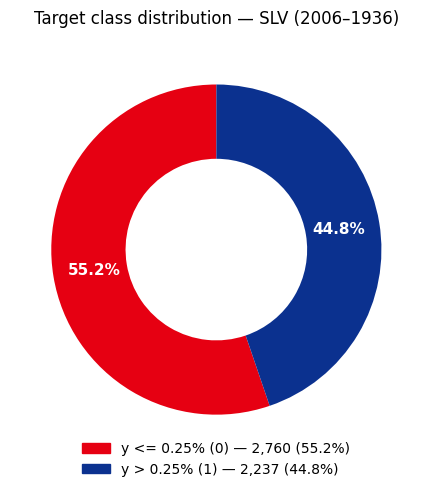

In [ ]:
# Trend
for p in [10, 20, 50]:
    df['EMA_'+str(p)] = df['Close'].ewm(span=p).mean()
    df['SMA_'+str(p)] = df['Close'].rolling(p).mean()

df['MACD_12_26'] = df['Close'].ewm(span=12).mean() - df['Close'].ewm(span=26).mean()
df['MACD_12_26_9'] = df['MACD_12_26'].ewm(span=9).mean()

# Momentum
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
df['RSI_14'] = 100 - (100 / (1 + gain / loss))
df['ROC_10'] = df['Close'].pct_change(10)
df['ROC_20'] = df['Close'].pct_change(20)

# Volatility
df['BB_mid_20'] = df['Close'].rolling(20).mean()
df['BB_std_20'] = df['Close'].rolling(20).std()
df['BB_upper_20'] = df['BB_mid_20'] + 2 * df['BB_std_20']
df['BB_lower_20'] = df['BB_mid_20'] - 2 * df['BB_std_20']
df['BB_width_20'] = (df['BB_upper_20'] - df['BB_lower_20']) / df['BB_mid_20'] # expressing band width as a percentage of price
df['BB_pos_20'] = (df['Close'] - df['BB_lower_20']) / (df['BB_upper_20'] - df['BB_lower_20'])
df['ATR_14'] = pd.concat([
    df['High'] - df['Low'], # intraday price movement
    (df['High'] - df['Close'].shift()).abs(), # max upward movement not captured by intraday
    (df['Low'] - df['Close'].shift()).abs(), # max downward movement not captured by intraday
], axis=1).max(axis=1).rolling(14).mean()

# Volume
df['Vol_SMA20'] = df['Volume'].rolling(20).mean()
df['Vol_ratio'] = df['Volume'] / df['Vol_SMA20'] # participation at time t relative to past 20 day average
df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).cumsum() # Assume all volumes follows the price direction

# Price structure
df['HL_range'] = (df['High'] - df['Low']) / df['Close'] # intraday gap normalised by a neutral reference point
df['OC_range'] = (df['Close'] - df['Open']) / df['Open'] # OC gap normalised by starting point

for p in range(1, 6):
    df['Ret_lag'+str(p)] = df['Return'].shift(p)

# small positive returns below 0.25% labeled as negative
df['Target'] = np.where(df['Close'].shift(-1) > 1.0025 * df['Close'], 1, 0)

# Record the features into a list
df.dropna(inplace=True)

cols_to_drop = [
    'BB_mid_20', 
    'BB_upper_20', 
    'BB_lower_20', 
    'BB_std_20', 
    'Vol_SMA20',
    'Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Return',
    'Target',
]
feature_list = [col for col in df.columns if col not in cols_to_drop]

# Donut chart for a peek into target class
counts = df['Target'].value_counts().sort_index()
labels = ['y <= 0.25% (0)', 'y > 0.25% (1)']
colors = {'blue': '#0B318F', 'red': '#E60012'}
colors_list = [colors['red'], colors['blue']]
sizes = counts.values

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors_list,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.45)
)

for at in autotexts:
    at.set_fontsize(11)
    at.set_color('white')
    at.set_fontweight('bold')

legend_patches = [
    mpatches.Patch(color=colors['red'], label=f'{labels[0]} — {sizes[0]:,} ({sizes[0]/sizes.sum()*100:.1f}%)'),
    mpatches.Patch(color=colors['blue'],  label=f'{labels[1]} — {sizes[1]:,} ({sizes[1]/sizes.sum()*100:.1f}%)')
]
ax.legend(handles=legend_patches, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=10)

ax.set_title('Target class distribution — SLV (2006–2026)', fontsize=12, pad=14)
plt.tight_layout()
plt.show()

The target variable $y_t$ is defined as a binary label indicating a meaningful upward price move on the following day:

$$y_t = \begin{cases} 1 & \text{if } \dfrac{Close_{t+1} - Close_t}{Close_t} > 0.0025 \\ 0 & \text{otherwise} \end{cases}$$

A threshold of 0.25% is applied to filter out near-flat days, so the model is trained to identify directionally significant upward moves to account for trading cost. The donut chart shows that 44.8% of observations are labelled as up day ($y=1$) and 55.2% as down day ($y=0$), reflecting a mild class imbalance that is addressed later in model construction via `scale_pos_weight`.

After constructing all technical indicators, the raw OHLCV columns along with the complementary columns used to construct final features are dropped as they carry no additional predictive information beyond what is already encoded in the engineered features. This yields a base candidate feature set of 23 features, listed as following.

In [8]:
print('Base list of features:')
for idx, feature in enumerate(feature_list):
    print(idx+1, feature)

Base list of features:
1 EMA_10
2 SMA_10
3 EMA_20
4 SMA_20
5 EMA_50
6 SMA_50
7 MACD_12_26
8 MACD_12_26_9
9 RSI_14
10 ROC_10
11 ROC_20
12 BB_width_20
13 BB_pos_20
14 ATR_14
15 Vol_ratio
16 OBV
17 HL_range
18 OC_range
19 Ret_lag1
20 Ret_lag2
21 Ret_lag3
22 Ret_lag4
23 Ret_lag5


In [9]:
# X with the initial set of features
X = df[feature_list]

X.describe().T

,count,mean,std,min,25%,50%,75%,max
EMA_10,4997.0,2.138889e+01,1.029065e+01,9.327837e+00,1.542088e+01,1.821632e+01,2.427040e+01,9.424458e+01
SMA_10,4997.0,2.138855e+01,1.030573e+01,9.367000e+00,1.537400e+01,1.824000e+01,2.424200e+01,9.248300e+01
EMA_20,4997.0,2.132926e+01,1.012453e+01,9.575970e+00,1.549065e+01,1.817222e+01,2.423049e+01,8.545035e+01
SMA_20,4997.0,2.132788e+01,1.015133e+01,9.495000e+00,1.544950e+01,1.809150e+01,2.419950e+01,8.411450e+01
EMA_50,4997.0,2.115350e+01,9.620306e+00,1.026614e+01,1.553919e+01,1.799589e+01,2.391599e+01,7.448068e+01
SMA_50,4997.0,2.115631e+01,9.723120e+00,9.814000e+00,1.550840e+01,1.803080e+01,2.410340e+01,7.853500e+01
MACD_12_26,4997.0,8.280822e-02,7.279218e-01,-3.830724e+00,-2.064197e-01,2.666726e-03,2.796920e-01,1.060977e+01
MACD_12_26_9,4997.0,8.193564e-02,6.780554e-01,-3.037319e+00,-1.978271e-01,-2.210707e-03,2.661549e-01,8.540364e+00
RSI_14,4997.0,5.150315e+01,1.802333e+01,0.000000e+00,3.823527e+01,5.169902e+01,6.443417e+01,9.675927e+01
ROC_10,4997.0,5.942930e-03,6.525199e-02,-3.584351e-01,-3.132997e-02,4.076094e-03,4.313731e-02,3.586626e-01


In [10]:
y = df['Target']

y.describe()

count    4997.000000
mean        0.447669
std         0.497304
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Target, dtype: float64

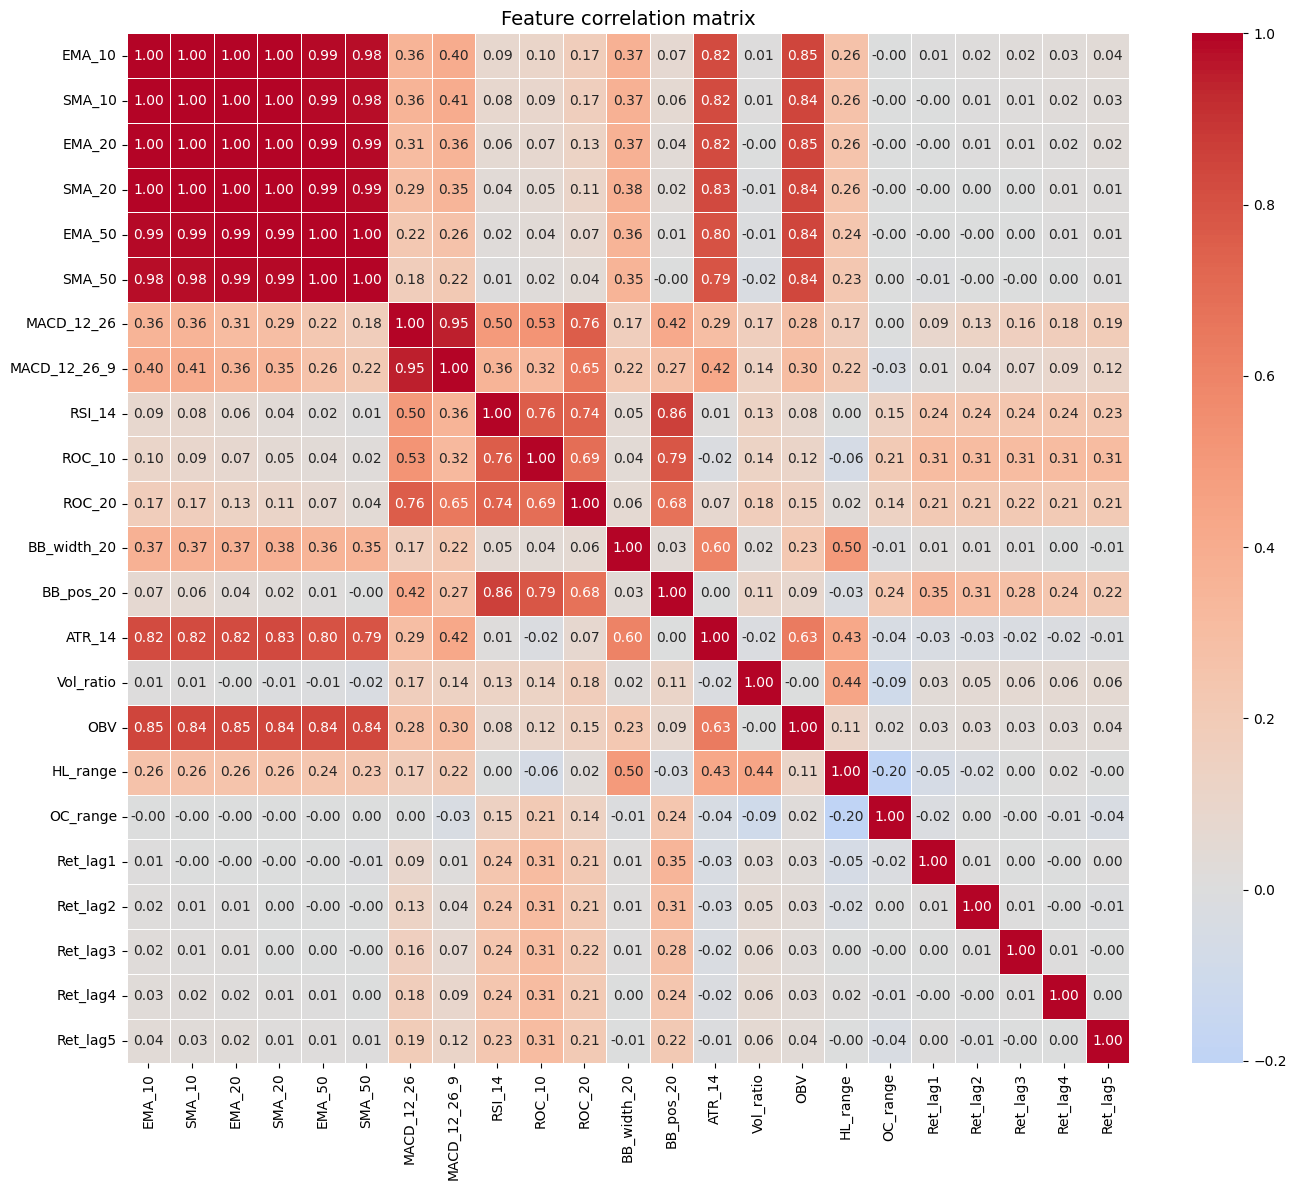

In [11]:
fix, ax = plt.subplots(figsize=(14, 12))
X_corr = X.corr()

sns.heatmap(X_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax)

ax.set_title('Feature correlation matrix', fontsize=14)
plt.tight_layout()
plt.show()

Feature selection is conducted in three sequential stages — filter, wrapper, and embedded — forming a funnelling approach. Running the methods in sequence is justified given that the filter stage removes redundant features cheaply using statistical criteria alone, before any model is fitted. This is crucial because highly correlated features cause multicollinearity, which destabilises model-based methods by splitting importance scores arbitrarily across redundant features. Passing a cleaner, smaller feature set to the wrapper and embedded stages improves both their reliability and computational efficiency. Each stage therefore hands a progressively more refined input to the next. The funnel reduces the original 23 features to 16 (filter), then to 11 (wrapper), and finally to 8 (embedded).

### B2. Filter method
For the filter method, we screen the features using pairwise Pearson correlation, independent of any model. Features that carry near-identical information introduce multicollinearity and add no predictive value. A correlation threshold of 0.85 is applied here. For each pair of features where $|r| > 0.85$ in the upper triangle of the correlation matrix, the latter feature (by column order) is dropped. This is a computationally inexpensive first pass that does not require model fitting, making it a natural opening stage of the funnel.

The correlation matrix reveals strong collinearity among the moving average family — `SMA_10`, `EMA_20`, `SMA_20`, `EMA_50`, `SMA_50` are all near-perfectly correlated with `EMA_10` given they track the same price series over similar horizons. `MACD_12_26_9` (the signal line) is highly correlated with `MACD_12_26` itself, and `BB_pos_20` correlates strongly with `RSI_14`. These 7 features are dropped, leaving 16 features for the next stage.

In [12]:
# Filter out all features with correlation more than 0.85 to prevent multicolinearity
abs_X_corr = X_corr.abs()
upper = abs_X_corr.where(np.triu(np.ones(abs_X_corr.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
filtered_feature_list = [f for f in feature_list if f not in to_drop_corr]

print("Dropped:", to_drop_corr)
print('List of features selected by filter method:')
for idx, feature in enumerate(filtered_feature_list):
    print(idx+1, feature)

Dropped: ['SMA_10', 'EMA_20', 'SMA_20', 'EMA_50', 'SMA_50', 'MACD_12_26_9', 'BB_pos_20']
List of features selected by filter method:
1 EMA_10
2 MACD_12_26
3 RSI_14
4 ROC_10
5 ROC_20
6 BB_width_20
7 ATR_14
8 Vol_ratio
9 OBV
10 HL_range
11 OC_range
12 Ret_lag1
13 Ret_lag2
14 Ret_lag3
15 Ret_lag4
16 Ret_lag5


In [13]:
# EDA on features by filter method
filtered_X = df[filtered_feature_list]

filtered_X.describe().T

,count,mean,std,min,25%,50%,75%,max
EMA_10,4997.0,2.138889e+01,1.029065e+01,9.327837e+00,1.542088e+01,1.821632e+01,2.427040e+01,9.424458e+01
MACD_12_26,4997.0,8.280822e-02,7.279218e-01,-3.830724e+00,-2.064197e-01,2.666726e-03,2.796920e-01,1.060977e+01
RSI_14,4997.0,5.150315e+01,1.802333e+01,0.000000e+00,3.823527e+01,5.169902e+01,6.443417e+01,9.675927e+01
ROC_10,4997.0,5.942930e-03,6.525199e-02,-3.584351e-01,-3.132997e-02,4.076094e-03,4.313731e-02,3.586626e-01
ROC_20,4997.0,1.172537e-02,9.211392e-02,-3.493906e-01,-4.483115e-02,4.416384e-03,6.312589e-02,5.997575e-01
BB_width_20,4997.0,1.314009e-01,8.354262e-02,2.478341e-02,7.713900e-02,1.136623e-01,1.578263e-01,6.660820e-01
ATR_14,4997.0,5.565324e-01,7.019743e-01,1.021427e-01,2.864286e-01,4.157145e-01,5.678573e-01,9.935713e+00
Vol_ratio,4997.0,1.016017e+00,4.988488e-01,1.551645e-01,6.876475e-01,8.948350e-01,1.213606e+00,9.319945e+00
OBV,4997.0,7.075736e+08,6.463473e+08,-1.771974e+08,2.633319e+08,5.037015e+08,1.069737e+09,4.137114e+09
HL_range,4997.0,1.887838e-02,1.363552e-02,3.275184e-03,1.081333e-02,1.548201e-02,2.290073e-02,3.051431e-01


In [14]:
# Import libraries for B3 and B4 works
from sklearn.feature_selection import RFECV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit, train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from statsmodels.stats.diagnostic import acorr_ljungbox

### B3. Wrapper method
Prior to feature selection, a Ljung-Box test is conducted on the return series up to lag 10 to test for serial autocorrelation. The null hypothesis is that returns are independently distributed with no autocorrelation structure. All 10 lags yield p-values well above 0.05, we fail to reject the null. The SLV return series exhibits no significant serial autocorrelation. This aligns with the weak-form efficient market hypothesis and foreshadows the difficulty of building a predictive model on this asset. 

Our wrapper method employs Recursive Feature Elimination with Cross-Validation (RFECV), using a `GradientBoostingClassifier` (100 estimators) as the evaluator. At each iteration, the weakest feature — as ranked by the estimator's internal importance scores — is eliminated one at a time (`step=1`). Receiver Operating Characteristic-Area Under Curve (ROC-AUC) is evaluated at each step using `TimeSeriesSplit` with 5 folds, which respects the temporal ordering of the data and prevents look-ahead bias. To prevent test-set information from influencing feature selection, RFECV is fitted on the training partition only (3,997 observations), with the selected feature mask then applied to both splits. The optimal number of features is selected as the subset that maximises the cross-validated ROC-AUC, subject to a minimum of 5 features. Unlike the filter method, the wrapper evaluates features in the context of a fitted model, capturing interaction effects between features rather than treating each independently. This reduces the 16 filter-selected features to 11.


In [15]:
lb_test = acorr_ljungbox(df['Return'], lags=10, return_df=True)
print(lb_test)

     lb_stat  lb_pvalue
1   0.107810   0.742651
2   0.111546   0.945754
3   0.291505   0.961618
4   0.342402   0.986915
5   2.041542   0.843368
6   2.443601   0.874725
7   2.708741   0.910576
8   4.606759   0.798660
9   9.292543   0.410720
10  9.450049   0.489990


In [16]:
# Split the dataset into training set and testing set
X_train_f, X_test_f, y_train, y_test = train_test_split(
    filtered_X, y, test_size=0.2, shuffle=False
)
print(f"\nTrain: {X_train_f.shape}, Test: {X_test_f.shape}")

# Split dataset into 5 splits, and set up gradient boosting model with 100 trees in an ensemble
tscv = TimeSeriesSplit(n_splits=5)

rfe = RFECV(
    estimator=GradientBoostingClassifier(n_estimators=100, random_state=42),
    step=1,
    cv=tscv,
    scoring='roc_auc',
    min_features_to_select=5
)

# Fit the model and pick the optimal features
rfe.fit(X_train_f, y_train)
rfe_feature_list = [f for f, s in zip(filtered_feature_list, rfe.support_) if s]

# Apply the selected feature mask to both splits
X_train_r = X_train_f[rfe_feature_list]
X_test_r  = X_test_f[rfe_feature_list]

print("List of optimal features selected by wrapper method:")
for idx, feature in enumerate(rfe_feature_list):
    print(idx+1, feature)



Train: (3997, 16), Test: (1000, 16)
List of optimal features selected by wrapper method:
1 EMA_10
2 ROC_10
3 BB_width_20
4 Vol_ratio
5 OBV
6 HL_range
7 OC_range
8 Ret_lag1
9 Ret_lag2
10 Ret_lag3
11 Ret_lag5


### B4. Embedded method
The embedded method extracts feature importance scores directly from a fitted model, selecting only features whose importance exceeds a defined threshold. Unlike the wrapper method which evaluates feature subsets via cross-validated performance, the embedded method scores each feature individually based on its contribution to the model's split decisions.

The 11 wrapper-selected features inherited the chronological 80/20 split established after the filter stage (3,997 training, 1,000 test observations). The embedded model is fitted on the training partition only, preventing any test-set information from influencing feature selection.

To address the mild class imbalance identified earlier, sample weights are computed via `compute_sample_weight(class_weight='balanced')`, upweighting the minority class during training. A `GradientBoostingClassifier` (100 estimators) is then fitted on the training set with these sample weights, and feature importances are extracted. Features with importance scores below the threshold of 0.08 are eliminated, reducing the 11 wrapper-selected features to 8 final features.


In [17]:
# Rebalance the labelled class because it was imbalanced
sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)

# Set up and fit model
gradient_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gradient_model.fit(X_train_r, y_train, sample_weight=sample_weight)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

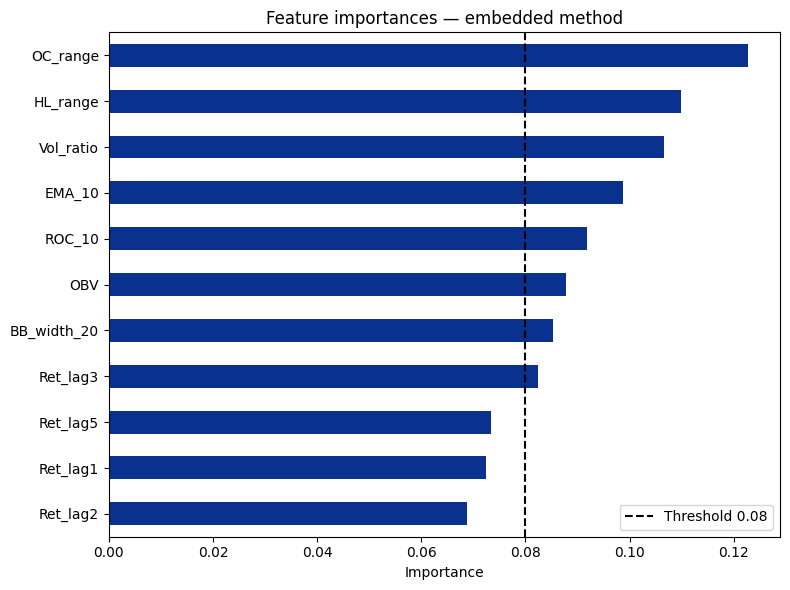

In [18]:
# Plot bar chart for feature importances
threshold = 0.08
importances = pd.Series(gradient_model.feature_importances_, index=rfe_feature_list).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 6), color=colors['blue'])
plt.axvline(x=threshold, color='black', linestyle='--', label='Threshold 0.08')
plt.title('Feature importances — embedded method')
plt.xlabel('Importance')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
# Pick out the features where their importance is greater than threshold
final_feature_list = importances[importances > threshold].index.to_list()

# Propagate the final feature mask to both splits
X_train_final = X_train_r[final_feature_list]
X_test_final  = X_test_r[final_feature_list]

print(f"List of features selected by embedded method:")
for idx, feature in enumerate(final_feature_list):
    print(idx+1, feature)

List of features selected by embedded method:
1 Ret_lag3
2 BB_width_20
3 OBV
4 ROC_10
5 EMA_10
6 Vol_ratio
7 HL_range
8 OC_range


In [20]:
# EDA on training set with final features
X_train_final.describe().T

,count,mean,std,min,25%,50%,75%,max
Ret_lag3,3997.0,1.424586e-04,1.988251e-02,-1.983489e-01,-8.332793e-03,8.398305e-04,9.773566e-03,1.347326e-01
BB_width_20,3997.0,1.263535e-01,7.932196e-02,2.478341e-02,7.404240e-02,1.086984e-01,1.527066e-01,5.688767e-01
OBV,3997.0,4.916670e+08,3.916181e+08,-1.771974e+08,2.057911e+08,4.433951e+08,6.603668e+08,1.679014e+09
ROC_10,3997.0,3.467366e-03,6.241100e-02,-3.055215e-01,-3.110661e-02,2.693003e-03,3.908592e-02,2.876481e-01
EMA_10,3997.0,1.905189e+01,6.421389e+00,9.327837e+00,1.452306e+01,1.670972e+01,2.211000e+01,4.479193e+01
Vol_ratio,3997.0,1.016603e+00,5.123853e-01,1.551645e-01,6.835632e-01,8.899331e-01,1.213355e+00,9.319945e+00
HL_range,3997.0,1.853310e-02,1.314692e-02,3.275184e-03,1.039085e-02,1.511909e-02,2.257181e-02,2.479591e-01
OC_range,3997.0,-2.162827e-04,1.330651e-02,-1.395961e-01,-6.009320e-03,0.000000e+00,6.040853e-03,1.080074e-01


In [21]:
# EDA on testing set with final features
X_test_final.describe().T

,count,mean,std,min,25%,50%,75%,max
Ret_lag3,1000.0,1.225544e-03,2.504171e-02,-3.360366e-01,-9.884741e-03,1.083461e-03,1.304601e-02,8.748747e-02
BB_width_20,1000.0,1.515755e-01,9.605517e-02,3.674054e-02,9.592143e-02,1.329213e-01,1.743111e-01,6.660820e-01
OBV,1000.0,1.570552e+09,7.374255e+08,9.139682e+08,1.073037e+09,1.256269e+09,1.747736e+09,4.137114e+09
ROC_10,1000.0,1.583776e-02,7.476839e-02,-3.584351e-01,-3.207583e-02,1.097796e-02,6.289695e-02,3.586626e-01
EMA_10,1000.0,3.072988e+01,1.598322e+01,1.700188e+01,2.106314e+01,2.550069e+01,3.043413e+01,9.424458e+01
Vol_ratio,1000.0,1.013675e+00,4.408382e-01,1.978037e-01,6.969631e-01,9.145169e-01,1.214192e+00,3.260287e+00
HL_range,1000.0,2.025844e-02,1.536470e-02,5.240184e-03,1.250492e-02,1.672466e-02,2.389983e-02,3.051431e-01
OC_range,1000.0,9.438466e-05,1.439342e-02,-1.554909e-01,-7.241988e-03,4.548666e-04,7.155484e-03,6.106621e-02


### B5. Final feature list

In [22]:
print('Feature selection summary:')
print(f"Original: {len(feature_list)} features")
print(f"After filter  : {len(filtered_feature_list)} features")
print(f"After wrapper : {len(rfe_feature_list)} features")
print(f"After embedded: {len(final_feature_list)} features")
print(f"\nFinal features: {final_feature_list}")

Feature selection summary:
Original: 23 features
After filter  : 16 features
After wrapper : 11 features
After embedded: 8 features

Final features: ['Ret_lag3', 'BB_width_20', 'OBV', 'ROC_10', 'EMA_10', 'Vol_ratio', 'HL_range', 'OC_range']


In [23]:
# Import libraries for works in C
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    classification_report
)
from sklearn.metrics import(
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)
import optuna
from sklearn.model_selection import cross_val_score
import pyfolio as pf

## C  — Model building, tuning and evaluation
### C1. Baseline model
XGBoost (`XGBClassifier`) is selected as the model for its four key enhancements over standard Gradient Boosting: (i) a regularisation term added to the loss function to penalise complex trees and control overfitting, (ii) use of both first and second derivatives of the loss (gradient and Hessian) for more precise step sizing, (iii) random feature subsampling at each split to decorrelate trees, and (iv) a highly optimised implementation for speed and memory efficiency. The 8 final features inherit the chronological 80/20 split established after the filter stage in Section B.

To address the mild class imbalance, `scale_pos_weight` is set to the ratio of negative to positive class observations in the training set:

$$scale\_pos\_weight = \frac{\text{count}(y=0)}{\text{count}(y=1)} = 1.2531$$

This penalises misclassification of the minority class (uptrend, $y=1$) proportionally during training. The baseline model is fitted with default hyperparameters and evaluated on the held-out test set using ROC-AUC, accuracy, and balanced accuracy.

In [24]:
# Reuse the split already established
X_train, X_test = X_train_final, X_test_final

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.4f}")

# Setup and fit XGBoost model
base_xgboost_model = XGBClassifier(
    verbosity=0, eval_metric='logloss', scale_pos_weight=scale_pos_weight
)

base_xgboost_model.fit(X_train, y_train)

scale_pos_weight: 1.2531


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [25]:
# Predicting the test set
y_pred = base_xgboost_model.predict(X_test)
y_prob = base_xgboost_model.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}')

ROC-AUC: 0.4817
Accuracy: 0.5010
Balanced accuracy: 0.4901


In [26]:
# Classification report for baseline model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.64      0.58       537
           1       0.45      0.34      0.39       463

    accuracy                           0.50      1000
   macro avg       0.49      0.49      0.48      1000
weighted avg       0.49      0.50      0.49      1000



The baseline model yields a ROC-AUC of 0.4817, accuracy of 50.1%, and balanced accuracy of 49.0% — all below the 0.50 random classifier benchmark. The classification report shows the model predicts the downtrend class more reliably (F1: 0.58) than the uptrend class (F1: 0.39), consistent with the sub-random ROC-AUC of 0.4817. The model has effectively no discriminative ability and performs worse than a random classifier overall. This sub-random performance backs the Ljung-Box findings in Section B, which showed no serial autocorrelation in SLV returns, suggesting the market is informationally efficient and directional moves are difficult to predict systematically.

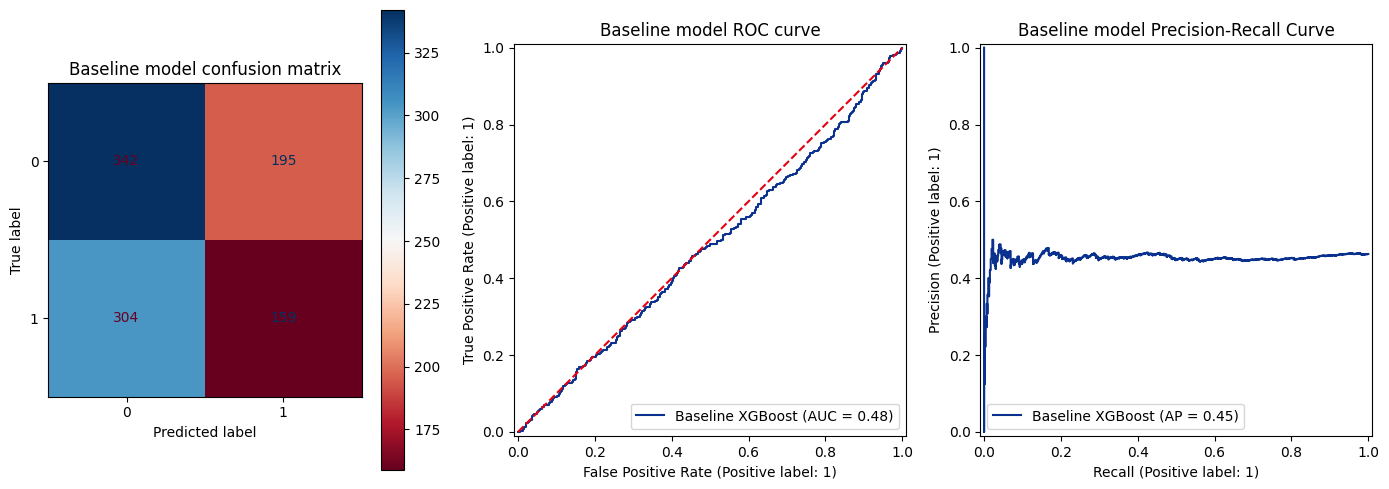

In [27]:
# Create a 1 by 3 figure
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Baseline confusion matrix
ConfusionMatrixDisplay.from_estimator(
    base_xgboost_model, X_test, y_test, 
    display_labels=base_xgboost_model.classes_, cmap='RdBu', ax=axes[0]
)
axes[0].set_title("Baseline model confusion matrix")

# Baseline ROC curve
disp_roc = RocCurveDisplay.from_estimator(
    base_xgboost_model, X_test, y_test,
    name='Baseline XGBoost', color=colors['blue'], ax=axes[1]
)

axes[1].set_title('Baseline model ROC curve')
axes[1].plot([0,1], [0,1], linestyle='--', color=colors['red'], label='Random classifier')

# Baseline PR curve
PrecisionRecallDisplay.from_estimator(
    base_xgboost_model, X_test, y_test,
    name='Baseline XGBoost', color=colors['blue'], ax=axes[2]
)

axes[2].set_title('Baseline model Precision-Recall Curve')

plt.tight_layout()
plt.show()

The confusion matrix shows the model correctly identifies 344 true downtrends (TN) and 157 true uptrends (TP), but generates 193 false uptrend signals (FP) and misses 306 actual uptrends (FN). The high FN count confirms the model is poorly calibrated for detecting upward moves.

The ROC curve lies predominantly below the random classifier diagonal (AUC = 0.48), confirming the model's discriminative ability is worse than chance. It is more likely to rank a downtrend day higher than an uptrend day than the other way around. The Precision-Recall (PR) curve yields an average precision (AP) of 0.45, with precision hovering flat around 0.40–0.50 across all recall thresholds, indicating no meaningful PR trade-off exists. The model produces no reliable uptrend signal at any threshold.

### C2. Hyperparameter tuning
Hyperparameter tuning is conducted via Bayesian optimisation using Optuna over 50 trials, maximising cross-validated ROC-AUC with `TimeSeriesSplit` (5 folds) to preserve temporal ordering. Bayesian optimisation is preferred over grid or random search as it builds a probabilistic surrogate model of the objective function, directing subsequent trials towards more promising regions of the search space.

The following hyperparameters are tuned within the specified search ranges:

| Hyperparameter | Range | Scale |
|---|---|---|
| `n_estimators` | 100 – 500 | linear |
| `max_depth` | 3 – 8 | linear |
| `learning_rate` | 0.01 – 0.30 | log |
| `subsample` | 0.60 – 1.00 | linear |
| `colsample_bytree` | 0.60 – 1.00 | linear |
| `min_child_weight` | 1 – 10 | linear |
| `reg_lambda` | 1e-3 – 10.0 | log |

The best trial yields a cross-validated AUC of 0.5196 with parameters: `n_estimators=294`, `max_depth=3`, `learning_rate=0.0196`, `subsample=0.7299`, `colsample_bytree=0.8423`, `min_child_weight=3`, `reg_lambda=0.4468`. 

In [28]:
# Tune XGBoost model via Bayesian search
def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight'  : scale_pos_weight,
        'eval_metric'       : 'logloss',
        'verbosity'         : 0
    }
    
    model = XGBClassifier(**params)
    tscv = TimeSeriesSplit(n_splits=5)
    scores = cross_val_score(
        model, X_train, y_train, cv=tscv, scoring='roc_auc'
    )
    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=50)

print(f"Best AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-05-25 20:59:24,194] A new study created in memory with name: no-name-e1d8b529-28f7-4d73-a83f-63aa45dec7da


[I 2026-05-25 20:59:26,781] Trial 0 finished with value: 0.49994161823285665 and parameters: {'n_estimators': 250, 'max_depth': 8, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'reg_lambda': 0.0017073967431528124}. Best is trial 0 with value: 0.49994161823285665.
[I 2026-05-25 20:59:29,355] Trial 1 finished with value: 0.4947181604565136 and parameters: {'n_estimators': 447, 'max_depth': 6, 'learning_rate': 0.11114989443094977, 'subsample': 0.608233797718321, 'colsample_bytree': 0.9879639408647978, 'min_child_weight': 9, 'reg_lambda': 0.0070689749506246055}. Best is trial 0 with value: 0.49994161823285665.
[I 2026-05-25 20:59:30,202] Trial 2 finished with value: 0.5130676331547291 and parameters: {'n_estimators': 172, 'max_depth': 4, 'learning_rate': 0.028145092716060652, 'subsample': 0.8099025726528951, 'colsample_bytree': 0.7727780074568463, 'min_child_weight': 3, 'reg_lambda': 0.2801635158716261}.

Best AUC: 0.5196
Best params: {'n_estimators': 294, 'max_depth': 3, 'learning_rate': 0.019630700268926382, 'subsample': 0.7298563128710828, 'colsample_bytree': 0.8422920131736712, 'min_child_weight': 3, 'reg_lambda': 0.4467539426971566}


In [29]:
# Fit tuned XGBoost model on full training set
tuned_xgboost_model = XGBClassifier(
    **study.best_params, scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', verbosity=0
) 

tuned_xgboost_model.fit(X_train, y_train)

# Evaluate on test set
tuned_y_pred = tuned_xgboost_model.predict(X_test)
tuned_y_prob = tuned_xgboost_model.predict_proba(X_test)[:, 1]

print(f"Tuned ROC-AUC  : {roc_auc_score(y_test, tuned_y_prob):.4f}")
print(f'Tuned accuracy: {accuracy_score(y_test, tuned_y_pred):.4f}')
print(f'Tuned balanced accuracy: {balanced_accuracy_score(y_test, tuned_y_pred):.4f}')

Tuned ROC-AUC  : 0.5081
Tuned accuracy: 0.5280
Tuned balanced accuracy: 0.5178


In [30]:
# Classification report for tuned model
print(classification_report(y_test, tuned_y_pred))

              precision    recall  f1-score   support

           0       0.55      0.66      0.60       537
           1       0.49      0.38      0.43       463

    accuracy                           0.53      1000
   macro avg       0.52      0.52      0.51      1000
weighted avg       0.52      0.53      0.52      1000



The tuned model is refitted on the full training set using these parameters and evaluated on the held-out test set, yielding a ROC-AUC of 0.5081, accuracy of 52.8%, and balanced accuracy of 51.8%. While this marks a marginal improvement over the baseline (ROC-AUC: 0.4817), performance remains random, and the uptrend class F1 improves modestly from 0.39 to 0.43. The results reinforce that SLV price direction is not meaningfully predictable from the selected set of features.

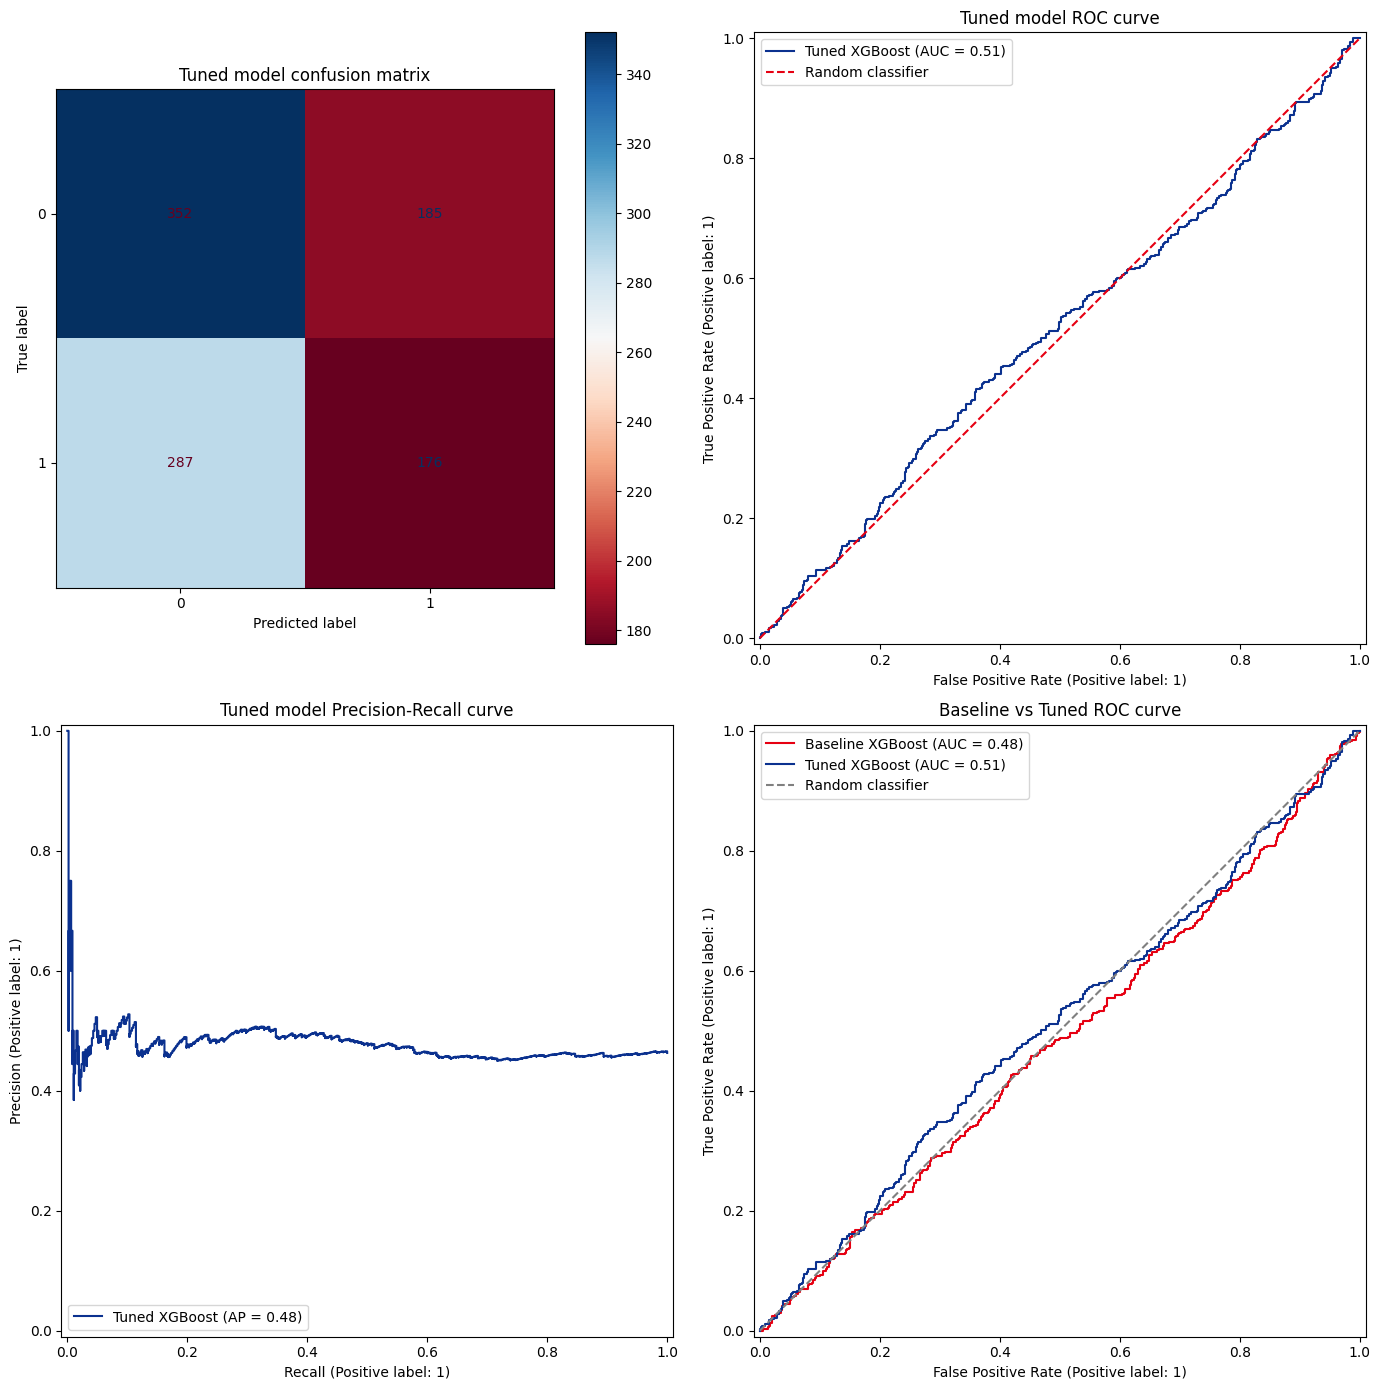

In [31]:
# Create a 2 by 2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# (0,0) Tuned confusion matrix
ConfusionMatrixDisplay.from_estimator(
    tuned_xgboost_model, X_test, y_test,
    display_labels=tuned_xgboost_model.classes_, cmap='RdBu', ax=axes[0, 0]
)
axes[0, 0].set_title('Tuned model confusion matrix')

# (0,1) Tuned ROC curve
RocCurveDisplay.from_estimator(
    tuned_xgboost_model, X_test, y_test,
    name='Tuned XGBoost', color=colors['blue'], ax=axes[0, 1]
)
axes[0, 1].plot([0,1], [0,1], linestyle='--', color=colors['red'], label='Random classifier')
axes[0, 1].set_title('Tuned model ROC curve')
axes[0, 1].legend()

# (1,0) Tuned PR curve
PrecisionRecallDisplay.from_estimator(
    tuned_xgboost_model, X_test, y_test,
    name='Tuned XGBoost', color=colors['blue'], ax=axes[1, 0]
)
axes[1, 0].set_title('Tuned model Precision-Recall curve')

# (1,1) Baseline vs Tuned ROC
RocCurveDisplay.from_estimator(
    base_xgboost_model, X_test, y_test,
    name='Baseline XGBoost', color=colors['red'], ax=axes[1, 1]
)
RocCurveDisplay.from_estimator(
    tuned_xgboost_model, X_test, y_test,
    name='Tuned XGBoost', color=colors['blue'], ax=axes[1, 1]
)
axes[1, 1].plot([0,1], [0,1], linestyle='--', color='grey', label='Random classifier')
axes[1, 1].set_title('Baseline vs Tuned ROC curve')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

The tuned confusion matrix shows 352 TN and 176 TP, with 185 FP and 287 FN. Compared to the baseline (344 TN, 157 TP), the tuned model correctly identifies more uptrend days (176 vs 157) with a marginally lower FP count (185 vs 193), reflecting a modest overall improvement in classification balance.

The tuned ROC curve (AUC = 0.51) now travels along the random classifier diagonal, confirming the tuned model is statistically indistinguishable from random but at least an improvement over the baseline (AUC = 0.48) which was actively worse than chance. The comparison panel (bottom right) illustrates this shift clearly, the baseline curve skews below the diagonal while the tuned curve tracks it closely. The PR curve (AP = 0.48) shows little improvement over the baseline (AP = 0.45), with precision briefly spiking to ~0.50 at very low recall before settling flat around 0.45, indicating no reliable operating point exists where the model achieves meaningfully high precision on uptrend signals.

### C3. Evaluation
The following depicts the importance of features by weight and gain respectively, sorted in ascending order.

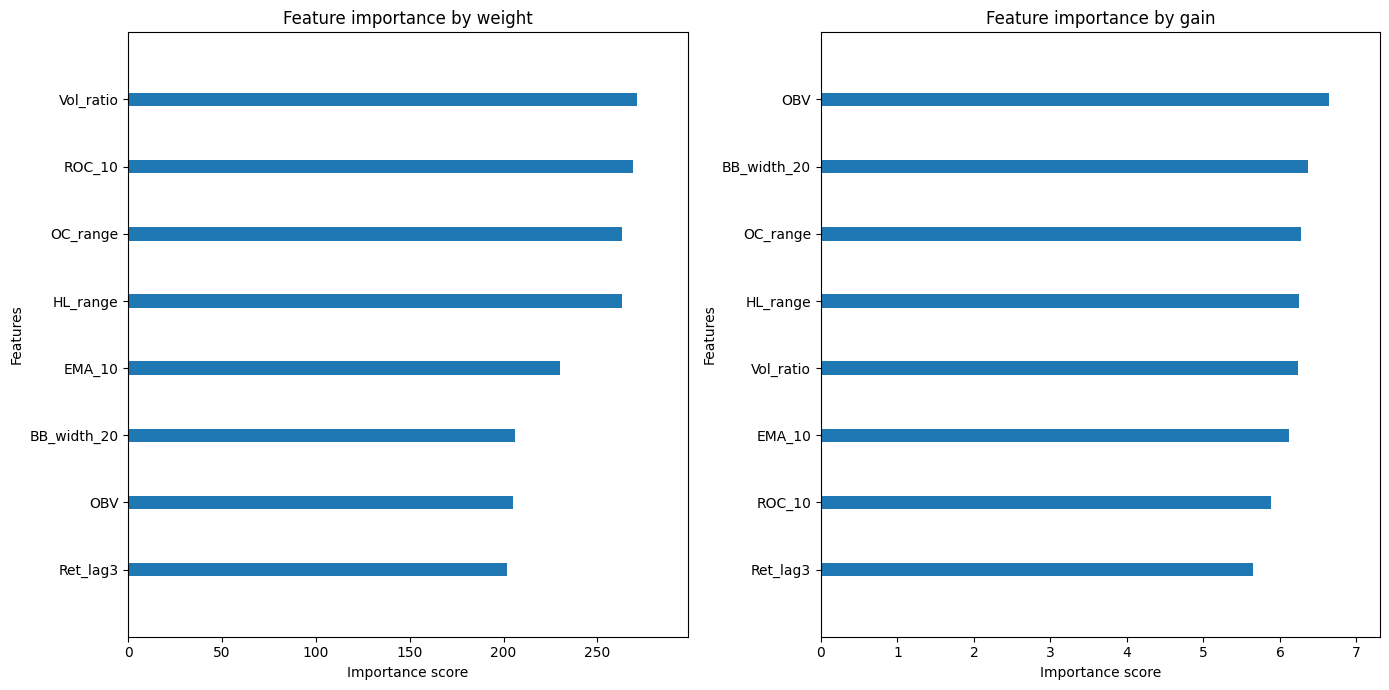

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# (0,0) Feature importance by weight
plot_importance(
    tuned_xgboost_model, importance_type='weight', 
    title='Feature importance by weight', show_values=False, ax=ax[0]
)

# (0,1) Feature importance by gain
plot_importance(
    tuned_xgboost_model, importance_type='gain',
    title='Feature importance by gain', show_values=False, ax=ax[1]
)

ax[0].grid(False)
ax[1].grid(False)
plt.tight_layout()
plt.show()

### C4. Backtesting
The tuned model is backtested over the test period (26 May 2022 – 20 May 2026, ~48 months) using a long-only strategy. The model takes a long position on days where it predicts an uptrend ($\hat{y}=1$) and holds cash otherwise. Transaction costs are not modelled. Performance is benchmarked against a passive buy-and-hold strategy on SLV over the same period.

Summary table:

| Metric | Strategy | Buy & Hold |
|---|---|---|
| Total return | 78.10% | 141.35% |
| Annual return | ~15.7% | — |
| Sharpe ratio (annualised) | 0.68 | 0.77 |
| Max drawdown | -37.08% | -49.56% |
| Sortino ratio | 0.87 | — |
| Calmar ratio | 0.42 | — |
| Beta | 0.48 | — |
| Alpha | 0.04 | — |
| Daily VaR | -3.41% | — |

The strategy substantially underperforms buy-and-hold on a total return basis (78.10% vs 141.35%), failing to capture the full extent of the silver rally over the test period as the model remained in cash on many of the strongly trending days. The cumulative returns chart confirms this divergence, with the strategy tracking well below the benchmark for much of the period.

That said, the strategy offers lower drawdown exposure. The maximum drawdown of -37.08% is 12.48 percentage points smaller than buy-and-hold's -49.56%, and the lower beta of 0.48 reflects the model's selective market participation — out of the market on most days, it naturally limits downside. The worst drawdown of 37.08% began on 28 Jan 2026 and had not recovered by the end of the test period, while the second and third worst drawdowns recovered within 161 and 228 trading days respectively.

The rolling 6-month Sharpe oscillates within the range of -1.00 and 4.00, reflecting the model's inconsistent signal quality over time. The near-zero alpha (0.04) confirms the strategy generates no risk-adjusted excess return over the benchmark. Overall, the backtesting results are in line with the model's random discriminative ability. The strategy reduces drawdown exposure relative to a passive position, but at a substantial opportunity cost in a trending bull market.

Strategy Performance vs Buy & Hold
                                   Strategy   Buy & Hold
--------------------------------------------------------
Total Return                         78.10%      141.35%
Sharpe Ratio (annualised)            0.6797       0.7687
Max Drawdown                        -37.08%      -49.56%


Start date,2022-05-25
End date,2026-05-20
Total months,47
,Backtest
Annual return,15.656%
Cumulative returns,78.1%
Annual volatility,27.645%
Sharpe ratio,0.68
Calmar ratio,0.42
Stability,0.90
Max drawdown,-37.08%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,37.08,2026-01-28,2026-05-19,NaT,NaN
1,14.09,2022-08-10,2022-10-14,2023-03-22,161
2,13.01,2024-09-24,2024-11-11,2025-08-07,228
3,10.43,2023-08-01,2024-03-22,2024-04-08,180
4,8.15,2024-07-17,2024-08-09,2024-08-27,30


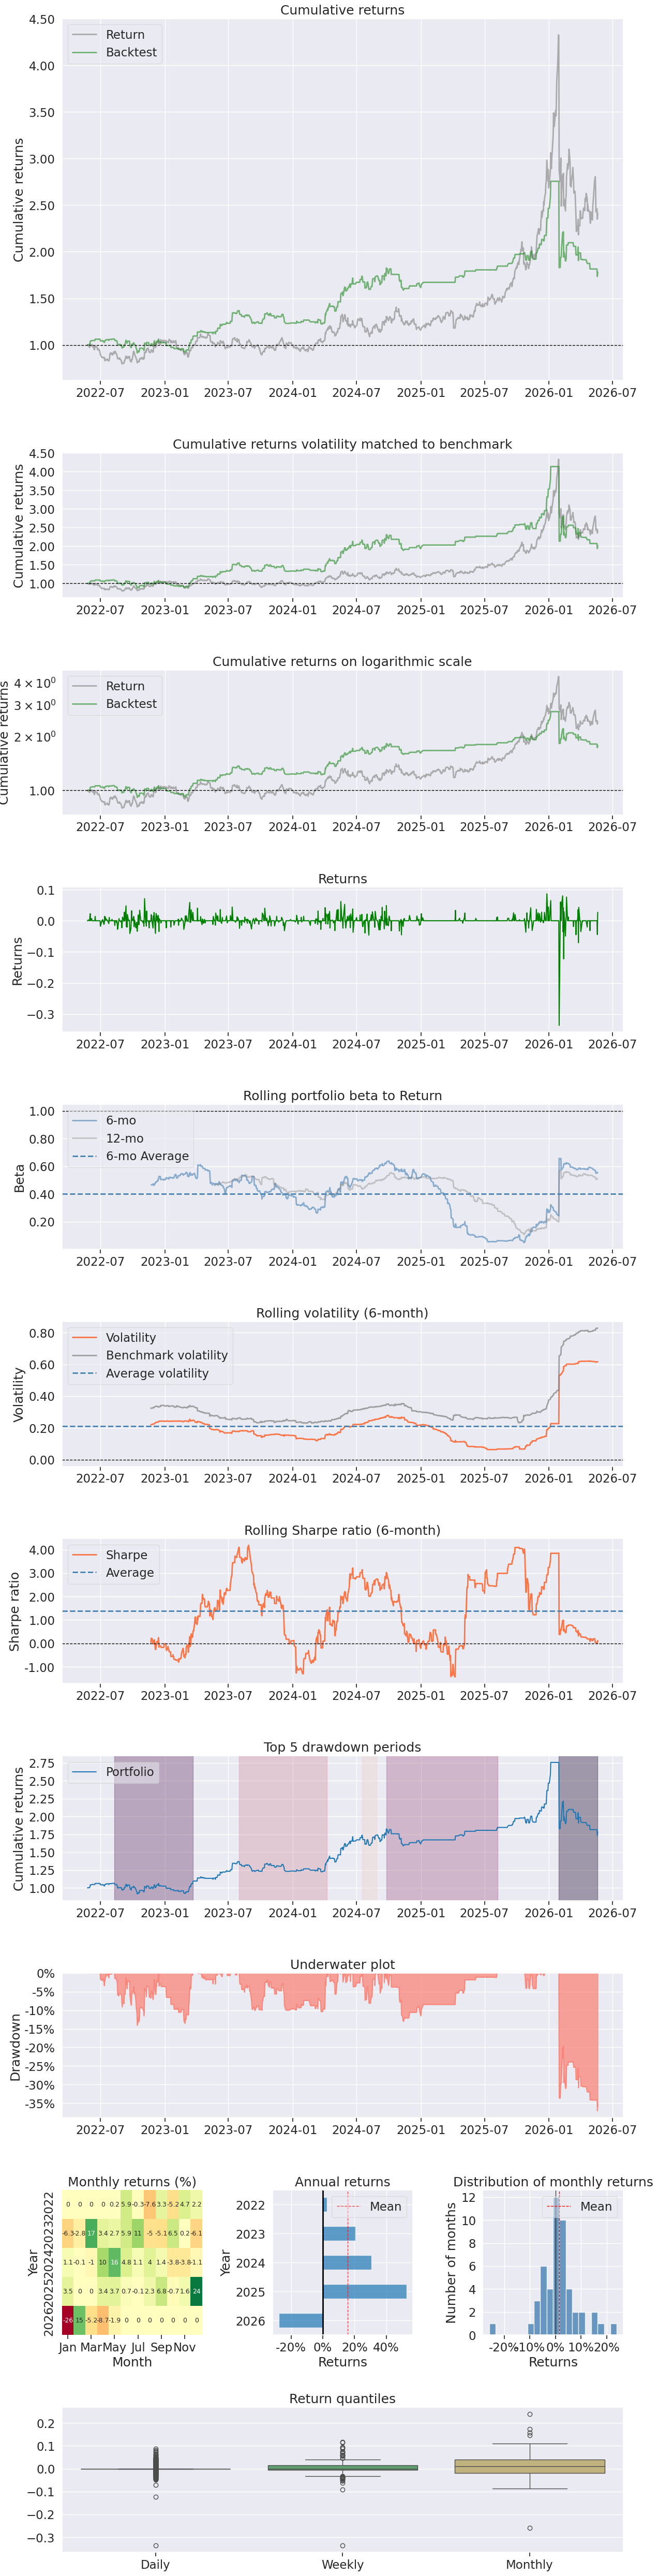

In [33]:
# Create a dataframe to backtest XGBoost strategy
backtest_df = X_test.copy()
backtest_df['Return'] = df.loc[X_test.index, 'Return']
backtest_df['Signal'] = tuned_y_pred
backtest_df['Strategy'] = backtest_df['Return'] * backtest_df['Signal'].shift(1).fillna(0)

# Strategy performance metrics
strat_cum = (1 + backtest_df['Strategy']).cumprod() - 1
bench_cum = (1 + backtest_df['Return']).cumprod() - 1
strat_sharpe = backtest_df['Strategy'].mean() / backtest_df['Strategy'].std() * np.sqrt(252)
bench_sharpe = backtest_df['Return'].mean() / backtest_df['Return'].std() * np.sqrt(252)
strat_total_return = strat_cum.iloc[-1]
bench_total_return = bench_cum.iloc[-1]
strat_wealth = 1 + strat_cum
bench_wealth = 1 + bench_cum
strat_max_dd = ((strat_wealth - strat_wealth.cummax()) / strat_wealth.cummax()).min()
bench_max_dd = ((bench_wealth - bench_wealth.cummax()) / bench_wealth.cummax()).min()

# Performance metrics printout
print("Strategy Performance vs Buy & Hold")
print(f"{'':30s} {'Strategy':>12} {'Buy & Hold':>12}")
print("-" * 56)
print(f"{'Total Return':30s} {strat_total_return:>12.2%} {bench_total_return:>12.2%}")
print(f"{'Sharpe Ratio (annualised)':30s} {strat_sharpe:>12.4f} {bench_sharpe:>12.4f}")
print(f"{'Max Drawdown':30s} {strat_max_dd:>12.2%} {bench_max_dd:>12.2%}")

# Create tear sheet for the strategy
pf.create_returns_tear_sheet(backtest_df['Strategy'], benchmark_rets=backtest_df['Return'])